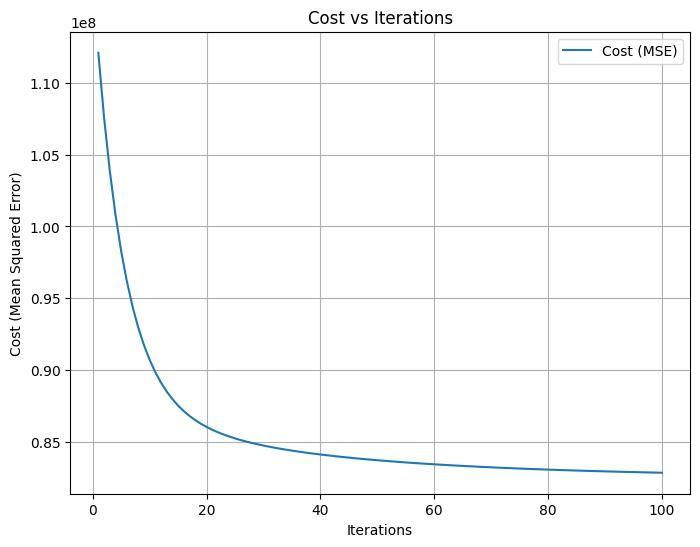

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/Users/arnav/Downloads/CarPrices/CarPrice_Assignment.csv')

# Preprocess the data
data = data.drop(columns=['car_ID'])

# Convert categorical columns to numerical using one-hot encoding
data = pd.get_dummies(data, drop_first=True)

# Separate the target variable (price) and features (X)
X = data.drop(columns=['price'])
y = data['price']

# Convert all features to numeric, coercing errors to NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Fill missing values with column means
X.fillna(X.mean(), inplace=True)
y = pd.to_numeric(y, errors='coerce').fillna(y.mean())

# Remove outliers based on price (e.g., prices above 3 standard deviations)
mean_price = y.mean()
std_price = y.std()
mask = (y > mean_price - 3 * std_price) & (y < mean_price + 3 * std_price)
X = X[mask]
y = y[mask]

# Drop any rows with NaN values after filtering
X = X.dropna()
y = y.loc[X.index]  # Align y with the filtered X

# Feature Engineering Enhancements
if 'engine_size' in X.columns:
    X['log_engine_size'] = np.log(X['engine_size'] + 1)

if 'horsepower' in X.columns:
    X['horsepower_squared'] = np.log(X['horsepower'] + 1) ** 2

if 'log_engine_size' in X.columns and 'horsepower' in X.columns:
    X['engine_horsepower_interaction'] = X['log_engine_size'] * np.log(X['horsepower'] + 1)

if 'year' in X.columns:
    X['year_bins'] = pd.cut(X['year'], bins=5, labels=False)

# Remove features with zero variance
zero_variance_columns = X.columns[X.var() == 0]
X.drop(columns=zero_variance_columns, inplace=True)

# Remove highly correlated features
def remove_highly_correlated_features(X, threshold=0.9):
    correlation_matrix = X.corr().abs()
    features_to_drop = set()
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if correlation_matrix.iloc[i, j] > threshold:
                colname = correlation_matrix.columns[i]
                features_to_drop.add(colname)
    X = X.drop(columns=features_to_drop)
    return X

X = remove_highly_correlated_features(X, threshold=0.9)

# Remove features with low variance
low_variance_columns = X.columns[X.var() < 1e-3]
X.drop(columns=low_variance_columns, inplace=True)

# Split the dataset into training and testing sets (80% train, 20% test)
train_size = int(0.8 * X.shape[0])
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# Feature Scaling: Standardize the data manually (mean=0, std=1) for each feature
def standardize(X_train, X_test):
    X_train = X_train.astype(float)
    X_test = X_test.astype(float)

    X_train_mean = np.mean(X_train, axis=0)
    X_train_std = np.std(X_train, axis=0)
   
    X_train_std[X_train_std == 0] = 1

    X_train_scaled = (X_train - X_train_mean) / X_train_std
    X_test_scaled = (X_test - X_train_mean) / X_train_std
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = standardize(X_train.to_numpy(), X_test.to_numpy())

# Ridge Regression with tracking of cost (MSE)
def ridge_regression(X, y, lambda_=1.0, num_iterations=100):
    identity_matrix = np.eye(X.shape[1])
    identity_matrix[0, 0] = 0  # Don't regularize the intercept term

    theta = np.zeros(X.shape[1])
    m = len(y)

    costs = []  # List to store the cost at each iteration

    for i in range(num_iterations):
        y_pred = X.dot(theta)
        residuals = y_pred - y
        cost = (1 / (2 * m)) * np.sum(residuals ** 2) + (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)
        costs.append(cost)

        gradient = (1 / m) * (X.T.dot(residuals) + lambda_ * np.r_[0, theta[1:]])  # Skip intercept regularization
        theta -= 0.01 * gradient  # Update step with learning rate 0.01

    return theta, costs

# Run Ridge Regression and collect costs
num_iterations = 100  # Number of iterations for tracking cost
lambda_value = 1.0  # You can adjust this as necessary
theta, costs = ridge_regression(X_train_scaled, y_train, lambda_=lambda_value, num_iterations=num_iterations)

# Plot Cost vs Iterations
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_iterations + 1), costs, label="Cost (MSE)")
plt.xlabel('Iterations')
plt.ylabel('Cost (Mean Squared Error)')
plt.title('Cost vs Iterations')
plt.grid(True)
plt.legend()
plt.show()